In [2]:
import pandas as pd
import os
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np

In [63]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Understanding the data

In [64]:
path_subject_1_control = '/content/drive/MyDrive/Colab Notebooks/DyslexIA/2emeDataset/Control/111GM3.csv'
df_subject_1_control = pd.read_csv(path_subject_1_control, index_col=0)
df_subject_1_control.head()

,T,LX,LY,RX,RY
0,0.0,0.00000,0.00000,0.00000,0.00000
1,20.0,0.65535,-0.00001,0.65536,-0.65536
2,40.0,0.65534,-0.00001,0.65536,-0.65536
3,60.0,0.65534,-0.00001,0.65535,-0.65536
4,80.0,0.65534,-0.00001,0.65534,0.00000


In [65]:
path_subject_1_dyslexic = '/content/drive/MyDrive/Colab Notebooks/DyslexIA/2emeDataset/Dyslexic/111JA2.csv'
df_subject_1_dyslexic = pd.read_csv(path_subject_1_dyslexic, index_col=0)
df_subject_1_dyslexic.head()

,T,LX,LY,RX,RY
0,0.0,0.00000,0.00000,0.00000,0.00000
1,20.0,-0.00001,0.00000,0.65535,-0.65536
2,40.0,-0.00001,-0.65537,0.65536,-1.31073
3,60.0,0.65536,-1.96609,0.65536,-1.96609
4,80.0,0.65536,-1.96609,1.31072,-1.96609


T: time --- LX, LY: left eye position (x, y) --- RX, RY: right eye position (x, y)

# Prepare the data

In [66]:
dossier_dyslexic = "/content/drive/MyDrive/Colab Notebooks/DyslexIA/2emeDataset/Dyslexic"
dossier_control = "/content/drive/MyDrive/Colab Notebooks/DyslexIA/2emeDataset/Control"

In [67]:
dyslexic_subject = [Path(f).stem for f in os.listdir(dossier_dyslexic) if f.endswith(".csv") and f != "Recording Data.csv"]
len(dyslexic_subject)

97

In [68]:
control_subject = [Path(f).stem for f in os.listdir(dossier_control) if f.endswith(".csv")]
len(control_subject)

88

### Create one file with all subject tagged

In [69]:
c = [[subject, 0, 'Control'] for subject in control_subject]
d = [[subject, 1, 'Dyslexic'] for subject in dyslexic_subject]
all_subjects = c + d
len(all_subjects)

185

In [70]:
subjects_class_label = pd.DataFrame(all_subjects, columns=['subject_id', 'class_id', 'label'])
subjects_class_label.head()

,subject_id,class_id,label
0,711TA3,0,Control
1,511YD3,0,Control
2,781SE4,0,Control
3,761SJ3,0,Control
4,825PA3,0,Control


In [71]:
subjects_class_label.to_csv("subjects.csv", float_format="%.2f")

### Create global features for standardization

In [72]:
subjects_global_data = subjects_class_label.copy()

data_subjects= []

for subject in all_subjects:
    path_subject = f'/content/drive/MyDrive/Colab Notebooks/DyslexIA/2emeDataset/{subject[2]}/{subject[0]}.csv'
    df_subject = pd.read_csv(path_subject, index_col=0)
    data_subjects.append([
        df_subject['T'].count(),
        df_subject['LX'].min(),
        df_subject['LX'].max(),
        df_subject['LY'].min(),
        df_subject['LY'].max(),
        df_subject['RX'].min(),
        df_subject['RX'].max(),
        df_subject['RY'].min(),
        df_subject['RY'].max()
    ])

subjects_global_data[['lenght', 'min_LX', 'max_LX', 'min_LY', 'max_LY', 'min_RX', 'max_RX', 'min_RY', 'max_RY']] = data_subjects

subjects_global_data

,subject_id,class_id,label,lenght,min_LX,max_LX,min_LY,max_LY,min_RX,max_RX,min_RY,max_RY
0,711TA3,0,Control,1499.0,-60.29352,258.87058,-186.12553,43.25464,-60.94880,258.21512,-188.74657,43.91001
1,511YD3,0,Control,999.0,-41.94139,185.47041,-176.29294,61.60438,-41.94276,187.43629,-176.29288,62.25973
2,781SE4,0,Control,1499.0,-46.53021,136.97361,-50.46338,41.28849,-46.52884,136.97361,-51.11874,40.63313
3,761SJ3,0,Control,1249.0,-23.59301,169.74041,-280.49754,53.74026,-41.94347,170.39580,-280.49757,53.74027
4,825PA3,0,Control,1499.0,-49.80822,76.02297,-115.34356,47.18656,-50.46358,75.36761,-113.37728,47.84193
...,...,...,...,...,...,...,...,...,...,...,...,...
180,125KM1,1,Dyslexic,1999.0,-39.97747,74.71476,-132.38472,1.96634,-39.97747,77.33363,-131.72935,40.63136
181,423MD1,1,Dyslexic,1999.0,-59.63730,127.79641,-36.70006,40.63258,-59.63684,127.79641,-36.04471,41.28792
182,751GS1,1,Dyslexic,1999.0,-52.42948,47.84251,-41.94313,41.94365,-52.42949,47.18709,-43.25385,41.28830
183,621NP2,1,Dyslexic,1999.0,-47.18596,123.20957,-71.43493,17.03973,-47.18528,123.86493,-72.09027,17.03973


In [73]:
subjects_global_data.describe()

,class_id,lenght,min_LX,max_LX,min_LY,max_LY,min_RX,max_RX,min_RY,max_RY
count,185.000000,185.000000,185.000000,185.000000,185.000000,185.000000,185.000000,185.000000,185.000000,185.000000
mean,0.524324,1746.297297,-49.867891,163.661365,-176.137082,43.845804,-49.835941,163.849100,-176.165428,42.605974
std,0.500763,320.272037,8.541772,61.708570,90.094415,12.855950,8.649860,61.956058,90.083353,14.032430
min,0.000000,999.000000,-67.503200,22.938160,-296.224070,0.000000,-77.333810,22.938170,-295.568960,0.000000
25%,0.000000,1499.000000,-57.015740,123.208880,-271.974540,40.632940,-57.016940,122.554450,-271.322530,40.632370
50%,1.000000,1999.000000,-49.807510,158.599290,-171.048290,43.254420,-49.807100,155.977770,-170.392950,42.599260
75%,1.000000,1999.000000,-43.253880,199.232670,-96.338960,52.428520,-43.253430,199.889100,-96.338970,52.429300
max,1.000000,1999.000000,-5.242750,294.256690,0.000000,64.881580,-13.762910,294.258830,0.000000,64.226220


Individuals:
- 185 individuals
- 52% class 1 (dyslexic) vs 48% class 0 → classes are almost balanced

Lengths:
- Min = 999, Max = 1999, Mean = 1746
- Most are at 1999 (the 25%, 50%, and 75% are all at 1999 or 1499)
- Choose T = 1999 as the target length; the short series will be padded

Coordinates:
- The values ​​range from -296 to +294 → these are not normalized 0-1 coordinates; they are probably in degrees or millimeters
- The min values ​​are negative → normal for a centered coordinate system
- The min_LY = 0.0 and min_RY = 0.0 at the 25th percentile are suspicious → possibly uncleaned error values

### Train test split

In [74]:
from sklearn.model_selection import train_test_split

X = subjects_class_label.drop(columns=['class_id', 'label'])
y = subjects_class_label['class_id']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [75]:
len(X_train)

148

recalculate global features on train set

In [76]:
config = {
    'features': ["LX", "LY", "RX", "RY"],
    "valid_min": -300,
    "valid_max": 300,
    "T": 1999
}

In [77]:
features = config["features"]
all_values = {f: [] for f in features}

for index, subject in X_train.iterrows():
    subject_id = subject['subject_id']
    filepath = f'/content/drive/MyDrive/Colab Notebooks/DyslexIA/2emeDataset/All/{subject_id}.csv'

    df = pd.read_csv(filepath, index_col=0)
    df_feat = df[features].copy()
    df_feat[df_feat < config["valid_min"]] = np.nan
    df_feat[df_feat > config["valid_max"]] = np.nan
    df_feat = df_feat.interpolate(method="linear").fillna(method="bfill").fillna(method="ffill")

    for f in features:
        all_values[f].extend(df_feat[f].values.tolist())

train_stats = {}
for f in features:
    vals = np.array(all_values[f])
    train_stats[f] = {"min": float(vals.min()), "max": float(vals.max())}

train_stats

/tmp/ipykernel_2616/88917437.py:12: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_feat = df_feat.interpolate(method="linear").fillna(method="bfill").fillna(method="ffill")
/tmp/ipykernel_2616/88917437.py:12: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_feat = df_feat.interpolate(method="linear").fillna(method="bfill").fillna(method="ffill")
/tmp/ipykernel_2616/88917437.py:12: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_feat = df_feat.interpolate(method="linear").fillna(method="bfill").fillna(method="ffill")
/tmp/ipykernel_2616/88917437.py:12: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_feat = df_feat.interpo

{'LX': {'min': -67.5032, 'max': 294.25669},
 'LY': {'min': -296.22407, 'max': 64.88158},
 'RX': {'min': -77.33381, 'max': 294.25883},
 'RY': {'min': -295.56896, 'max': 64.22622}}

process one csv

In [78]:
def process_single_file(filepath, train_stats, config):
    """
    Transforme un CSV en tableau numpy de shape (T, 4).
    Retourne None si le traitement échoue.
    """
    features = config["features"]
    T = config["T"]

    df = pd.read_csv(filepath, index_col=0)
    df_feat = df[features].copy()

    # --- Étape A : Remplacer les valeurs aberrantes par NaN ---
    df_feat[df_feat < config["valid_min"]] = np.nan
    df_feat[df_feat > config["valid_max"]] = np.nan

    # --- Étape B : Interpolation linéaire pour combler les NaN ---
    # interpolate comble les NaN entre deux valeurs valides
    # bfill/ffill gèrent les NaN au début et à la fin de la série
    df_feat = df_feat.interpolate(method="linear")
    df_feat = df_feat.fillna(method="bfill").fillna(method="ffill")

    # Si encore des NaN après tout ça, abandonner ce fichier
    if df_feat.isna().any().any():
        return None

    # --- Étape C : Normalisation Min-Max avec les stats du TRAIN ---
    # Formule : (x - min_train) / (max_train - min_train)
    # On clip pour forcer les valeurs entre 0 et 1 même si test dépasse le train
    for f in features:
        f_min = train_stats[f]["min"]
        f_max = train_stats[f]["max"]
        df_feat[f] = (df_feat[f] - f_min) / (f_max - f_min)
        df_feat[f] = df_feat[f].clip(0, 1)  # sécurité

    # --- Étape D : Uniformiser à la longueur T ---
    arr = df_feat.values  # shape (longueur_actuelle, 4)

    if len(arr) >= T:
        # Série trop longue : on garde les T premiers timesteps
        arr = arr[:T, :]
    else:
        # Série trop courte : on ajoute des zéros à la fin (zero-padding)
        pad_length = T - len(arr)
        padding = np.zeros((pad_length, len(features)))
        arr = np.vstack([arr, padding])

    # Vérification finale de shape
    assert arr.shape == (T, len(features)), f"Shape inattendue : {arr.shape}"

    return arr.astype(np.float32)

prosses all train

In [79]:
X_list = []

for subject in all_subjects:
    subject_id = subject[0]
    filepath = f'/content/drive/MyDrive/Colab Notebooks/DyslexIA/2emeDataset/All/{subject_id}.csv'

    arr = process_single_file(filepath, train_stats, config)

    X_list.append(arr)

X_pros = np.stack(X_list, axis=0)
len(X_pros)

/tmp/ipykernel_2616/733940144.py:20: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_feat = df_feat.fillna(method="bfill").fillna(method="ffill")
/tmp/ipykernel_2616/733940144.py:20: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_feat = df_feat.fillna(method="bfill").fillna(method="ffill")
/tmp/ipykernel_2616/733940144.py:20: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_feat = df_feat.fillna(method="bfill").fillna(method="ffill")
/tmp/ipykernel_2616/733940144.py:20: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_feat = df_feat.fillna(method="bfill").fillna(method="ffill")
/tmp/ipykernel_2616/733940144.py:20: FutureW

185

In [80]:
len(X_pros),len(X_pros[0]), len(X_pros[0][0])

(185, 1999, 4)

In [81]:
subjects_class_label.iloc[12]

,12
subject_id,725OM3
class_id,0
label,Control


In [82]:
X_train

,subject_id
39,701AA4
68,761NM3
131,112KA1
66,753PJ3
30,714GC4
...,...
27,133GJ3
100,142EJ1
97,701LV2
178,533KM1


In [83]:
X_train.iloc[0].name

np.int64(39)

~150 indi and T=1999 in train set

In [84]:
def build_dataset(subject_df, subjects_class_label, train_stats, config):
    X_list = []
    y_list = []

    for index, subject in subject_df.iterrows():
        subject_id = subject['subject_id']
        label_str = subjects_class_label.loc[index, 'label']  # 'Dyslexic' ou 'Control'
        filepath = f'/content/drive/MyDrive/Colab Notebooks/DyslexIA/2emeDataset/{label_str}/{subject_id}.csv'

        arr = process_single_file(filepath, train_stats, config)
        if arr is not None:
            X_list.append(arr)
            y_list.append(subjects_class_label.loc[index, 'class_id'])

    X = np.stack(X_list, axis=0)
    y = np.array(y_list)
    return X, y

# Construire train et test proprement
X_train_pros, y_train_clean = build_dataset(X_train, subjects_class_label, train_stats, config)
X_test_pros, y_test_clean   = build_dataset(X_test,  subjects_class_label, train_stats, config)

print(X_train_pros.shape)  # (148, 1999, 4)
print(y_train_clean.mean()) # ~0.52

/tmp/ipykernel_2616/733940144.py:20: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_feat = df_feat.fillna(method="bfill").fillna(method="ffill")
/tmp/ipykernel_2616/733940144.py:20: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_feat = df_feat.fillna(method="bfill").fillna(method="ffill")
/tmp/ipykernel_2616/733940144.py:20: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_feat = df_feat.fillna(method="bfill").fillna(method="ffill")
/tmp/ipykernel_2616/733940144.py:20: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_feat = df_feat.fillna(method="bfill").fillna(method="ffill")
/tmp/ipykernel_2616/733940144.py:20: FutureW

(148, 1999, 4)
0.527027027027027


/tmp/ipykernel_2616/733940144.py:20: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_feat = df_feat.fillna(method="bfill").fillna(method="ffill")
/tmp/ipykernel_2616/733940144.py:20: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_feat = df_feat.fillna(method="bfill").fillna(method="ffill")
/tmp/ipykernel_2616/733940144.py:20: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_feat = df_feat.fillna(method="bfill").fillna(method="ffill")


In [101]:
X_train_pros.shape

(148, 1999, 4)

In [104]:
y_train_clean.shape

(148,)

In [102]:
X_test_pros.shape

(37, 1999, 4)

In [103]:
y_test_clean.shape

(37,)

## CNN Model 1D

In [105]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Input, Conv1D, BatchNormalization,
    MaxPooling1D, Dropout, GlobalAveragePooling1D, Dense
)
from tensorflow import keras
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

In [106]:
def initialize_model():
    model = Sequential()

    model.add(Input(shape=(1999, 4)))

    model.add(Conv1D(32, kernel_size=7, activation='relu', padding='same'))
    model.add(BatchNormalization())
    model.add(MaxPooling1D(pool_size=2))
    model.add(Dropout(0.3))

    model.add(Conv1D(64, kernel_size=5, padding="same", activation="relu"))
    model.add(BatchNormalization())
    model.add(MaxPooling1D(pool_size=2))
    model.add(Dropout(0.3))

    model.add(Conv1D(128, kernel_size=3, padding="same", activation="relu"))
    model.add(BatchNormalization())
    model.add(MaxPooling1D(pool_size=2))
    model.add(Dropout(0.3))

    model.add(GlobalAveragePooling1D())

    model.add(Dense(64, activation="relu"))
    model.add(Dropout(0.5))
    model.add(Dense(1, activation="sigmoid"))

    return model

In [107]:
def compile_model(model):
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss="binary_crossentropy",
        metrics=[
            "accuracy",
            keras.metrics.AUC(name="auc"),
            "recall"
        ],
    )
    return model

In [108]:
callbacks = [
    EarlyStopping(
        monitor="val_loss",
        patience=15,
        restore_best_weights=True,
        verbose=1,
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=7,
        min_lr=1e-6,
        verbose=1,
    ),
]

In [109]:
model = initialize_model()
model = compile_model(model)

history = model.fit(
    X_train_pros, y_train_clean,
    validation_split=0.2,
    batch_size=16,
    epochs=150,
    shuffle=True,
    callbacks=callbacks,
    verbose=1,
)

Epoch 1/150
8/8 ━━━━━━━━━━━━━━━━━━━━ 18s 1s/step - accuracy: 0.6780 - auc: 0.7540 - loss: 0.6404 - recall: 0.9000 - val_accuracy: 0.6000 - val_auc: 0.6852 - val_loss: 0.6785 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 2/150
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.8644 - auc: 0.8865 - loss: 0.4146 - recall: 0.9333 - val_accuracy: 0.6000 - val_auc: 0.7500 - val_loss: 0.6701 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 3/150
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.9068 - auc: 0.9287 - loss: 0.3208 - recall: 0.9500 - val_accuracy: 0.6000 - val_auc: 0.6597 - val_loss: 0.6705 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 4/150
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.9322 - auc: 0.9552 - loss: 0.2743 - recall: 0.9500 - val_accuracy: 0.6000 - val_auc: 0.6944 - val_loss: 0.6785 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 5/150
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.9068 - auc: 0.9484 - loss: 0.2739 - recall: 0.9167 - val_

In [110]:
def plot_history(history, title='', axs=None, exp_name=""):
    if axs is not None:
        ax1, ax2 = axs
    else:
        f, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    if len(exp_name) > 0 and exp_name[0] != '_':
        exp_name = '_' + exp_name
    ax1.plot(history.history['loss'], label = 'train' + exp_name)
    ax1.plot(history.history['val_loss'], label = 'val' + exp_name)
    ax1.set_ylim(0., 2.2)
    ax1.set_title('loss')
    ax1.legend()

    ax2.plot(history.history['recall'], label='train recall'  + exp_name)
    ax2.plot(history.history['val_recall'], label='val recall'  + exp_name)
    ax2.set_ylim(0.25, 1.)
    ax2.set_title('Recall')
    ax2.legend()
    return (ax1, ax2)

(<Axes: title={'center': 'loss'}>, <Axes: title={'center': 'Recall'}>)

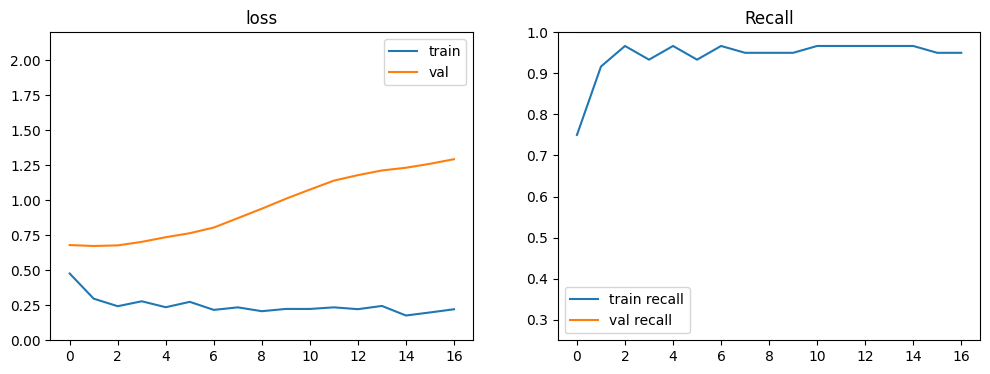

In [93]:
plot_history(history)

In [111]:
model.evaluate(X_test_pros, y_test_clean)

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 629ms/step - accuracy: 0.5135 - auc: 0.6857 - loss: 0.6989 - recall: 1.0000


[0.6988840699195862, 0.5135135054588318, 0.6856724619865417, 1.0]

The model is overfitting

In [112]:
def initialize_model():
    model = Sequential()

    model.add(Input(shape=(1999, 4)))

    model.add(Conv1D(16, kernel_size=7, padding="same", activation="relu"))
    model.add(BatchNormalization())
    model.add(MaxPooling1D(pool_size=2))
    model.add(Dropout(0.4))

    model.add(Conv1D(32, kernel_size=5, padding="same", activation="relu"))
    model.add(BatchNormalization())
    model.add(MaxPooling1D(pool_size=2))
    model.add(Dropout(0.4))

    model.add(GlobalAveragePooling1D())

    model.add(Dense(64, activation="relu"))
    model.add(Dropout(0.5))
    model.add(Dense(1, activation="sigmoid"))

    return model

In [113]:
from sklearn.model_selection import StratifiedKFold

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
val_scores = []
val_scores_recall = []

for fold, (train_idx, val_idx) in enumerate(kf.split(X_train_pros, y_train_clean)):
    print(f"\n--- Fold {fold+1}/5 ---")
    X_tr, X_val = X_train_pros[train_idx], X_train_pros[val_idx]
    y_tr, y_val = y_train[train_idx], y_train[val_idx]

    model = initialize_model()
    model = compile_model(model)
    model.fit(X_tr, y_tr, validation_data=(X_val, y_val),
              batch_size=32, epochs=150, callbacks=callbacks, verbose=0)

    _, acc, auc, recall = model.evaluate(X_val, y_val, verbose=0)
    val_scores.append(acc)
    val_scores_recall.append(recall)
    print(f"Accuracy fold {fold+1} : {acc:.3f}")
    print(f"Recall fold {fold+1} : {recall:.3f}")

print(f"\nAccuracy moyenne : {np.mean(val_scores):.3f} ± {np.std(val_scores):.3f}")
print(f"\nRecall moyenne : {np.mean(val_scores_recall):.3f} ± {np.std(val_scores_recall):.3f}")


--- Fold 1/5 ---

Epoch 7: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 14: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
Epoch 15: early stopping
Restoring model weights from the end of the best epoch: 1.
Accuracy fold 1 : 0.533
Recall fold 1 : 1.000

--- Fold 2/5 ---

Epoch 7: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 14: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
Epoch 15: early stopping
Restoring model weights from the end of the best epoch: 1.
Accuracy fold 2 : 0.533
Recall fold 2 : 1.000

--- Fold 3/5 ---

Epoch 12: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 19: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
Epoch 20: early stopping
Restoring model weights from the end of the best epoch: 5.
Accuracy fold 3 : 0.533
Recall fold 3 : 1.000

--- Fold 4/5 ---

Epoch 7: ReduceLROnPlateau reducing learning rate to 0.0005000000237487

In [114]:
print(X_train_pros.shape)  # doit être (148, 1999, 4)
print(y_train.shape)       # doit être (148,)
print(y_train.mean())      # doit être ~0.52
print(X_train_pros.min(), X_train_pros.max())  # doit être entre 0 et 1

(148, 1999, 4)
(148,)
0.527027027027027
0.0 1.0


New model is overfitting too

In [115]:
def initialize_model():
    model = Sequential()
    model.add(Input(shape=(1999, 4)))

    model.add(Conv1D(16, kernel_size=7, padding="same", activation="relu"))
    model.add(MaxPooling1D(pool_size=4))
    model.add(Dropout(0.3))

    model.add(Conv1D(32, kernel_size=5, padding="same", activation="relu"))
    model.add(MaxPooling1D(pool_size=4))
    model.add(Dropout(0.3))

    model.add(GlobalAveragePooling1D())
    model.add(Dense(16, activation="relu"))
    model.add(Dropout(0.5))
    model.add(Dense(1, activation="sigmoid"))

    return model

In [116]:
def compile_model(model):
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-4),
        loss="binary_crossentropy",
        metrics=[
            "accuracy",
            keras.metrics.AUC(name="auc"),
            "recall"
        ],
    )
    return model

In [117]:
callbacks = [
    EarlyStopping(
        monitor="val_loss",
        patience=20,
        restore_best_weights=True,
        verbose=1,
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=10,
        min_lr=1e-6,
        verbose=1,
    ),
]

In [119]:
model = initialize_model()
model = compile_model(model)

history = model.fit(
    X_train_pros, y_train_clean,
    validation_split=0.2,
    batch_size=16,
    epochs=150,
    shuffle=True,
    callbacks=callbacks,
    verbose=1,
)

Epoch 1/150
8/8 ━━━━━━━━━━━━━━━━━━━━ 11s 664ms/step - accuracy: 0.5508 - auc: 0.5408 - loss: 0.7054 - recall: 0.3500 - val_accuracy: 0.4000 - val_auc: 0.3611 - val_loss: 0.7060 - val_recall: 0.0000e+00 - learning_rate: 1.0000e-04
Epoch 2/150
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.5169 - auc: 0.4504 - loss: 0.7353 - recall: 0.4333 - val_accuracy: 0.4000 - val_auc: 0.4468 - val_loss: 0.7005 - val_recall: 0.0000e+00 - learning_rate: 1.0000e-04
Epoch 3/150
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.4746 - auc: 0.4655 - loss: 0.7312 - recall: 0.4167 - val_accuracy: 0.4333 - val_auc: 0.5324 - val_loss: 0.6965 - val_recall: 0.0556 - learning_rate: 1.0000e-04
Epoch 4/150
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.4831 - auc: 0.4749 - loss: 0.7214 - recall: 0.4000 - val_accuracy: 0.6000 - val_auc: 0.6319 - val_loss: 0.6920 - val_recall: 0.4444 - learning_rate: 1.0000e-04
Epoch 5/150
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.5932 - auc: 0.5556 - loss: 0.6

In [120]:
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
val_scores = []
val_scores_recall = []

for fold, (train_idx, val_idx) in enumerate(kf.split(X_train_pros, y_train_clean)):
    print(f"\n--- Fold {fold+1}/5 ---")
    X_tr, X_val = X_train_pros[train_idx], X_train_pros[val_idx]
    y_tr, y_val = y_train[train_idx], y_train[val_idx]

    model = initialize_model()
    model = compile_model(model)
    model.fit(X_tr, y_tr, validation_data=(X_val, y_val),
              batch_size=16, epochs=150, callbacks=callbacks, verbose=0)

    _, acc, auc, recall = model.evaluate(X_val, y_val, verbose=0)
    val_scores.append(acc)
    val_scores_recall.append(recall)
    print(f"Accuracy fold {fold+1} : {acc:.3f}")
    print(f"Recall fold {fold+1} : {recall:.3f}")

print(f"\nAccuracy moyenne : {np.mean(val_scores):.3f} ± {np.std(val_scores):.3f}")
print(f"\nRecall moyenne : {np.mean(val_scores_recall):.3f} ± {np.std(val_scores_recall):.3f}")


--- Fold 1/5 ---

Epoch 10: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.

Epoch 20: ReduceLROnPlateau reducing learning rate to 2.499999936844688e-05.
Epoch 20: early stopping
Restoring model weights from the end of the best epoch: 1.
Accuracy fold 1 : 0.467
Recall fold 1 : 0.000

--- Fold 2/5 ---

Epoch 10: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.

Epoch 20: ReduceLROnPlateau reducing learning rate to 2.499999936844688e-05.
Epoch 20: early stopping
Restoring model weights from the end of the best epoch: 1.
Accuracy fold 2 : 0.433
Recall fold 2 : 0.625

--- Fold 3/5 ---

Epoch 10: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.

Epoch 20: ReduceLROnPlateau reducing learning rate to 2.499999936844688e-05.
Epoch 20: early stopping
Restoring model weights from the end of the best epoch: 1.
Accuracy fold 3 : 0.533
Recall fold 3 : 1.000

--- Fold 4/5 ---

Epoch 10: ReduceLROnPlateau reducing learning rate to 4.9999998736893